Lab 6: Decision Tree
Jorge Angon, Faith Yang

https://www.kaggle.com/datasets/alyabdelnaby/data-banknote-authentication

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics


# load dataset
df = pd.read_csv("data_banknote_authentication.csv")
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


In [ ]:
# remove the one bad row so the target stays binary
df = df[df["Class"].isin([0, 1, 0.0, 1.0])]
df["Class"] = df["Class"].astype(int)

# class meaning:
# 0 = Authentic
# 1 = Forged

# split dataset in features and target variable
x_data = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']]
y_data = df['Class']

In [ ]:
# split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1) # 70% training and 30% test

In [ ]:
# create Decision Tree classifer object
dt_model = DecisionTreeClassifier()

# train Decision Tree Classifer
dt_model2 = dt_model.fit(X_train, y_train)

# predict the response for test dataset
y_pred = dt_model2.predict(X_test)

In [ ]:
# model Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9830097087378641


In [ ]:
# measure precision, recall, and f1 score.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"The precision of the model is {precision:.2f}.")
print(f"The recall of the model is {recall:.2f}.")
print(f"The F1-score of the model is {f1:.2f}.")

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       235
           1       0.97      0.99      0.98       177

    accuracy                           0.98       412
   macro avg       0.98      0.98      0.98       412
weighted avg       0.98      0.98      0.98       412

The precision of the model is 0.97.
The recall of the model is 0.99.
The F1-score of the model is 0.98.


In [ ]:
# Prepare a provision for a new data entry and its prediction of an outcome.

def predict_banknote():
    while True:
        try:
            variance = float(input("Enter variance: "))
            skewness = float(input("Enter skewness: "))
            curtosis = float(input("Enter curtosis: "))
            entropy = float(input("Enter entropy: "))

            new_banknote_data = pd.DataFrame([[variance, skewness, curtosis, entropy]],
                                             columns=['Variance', 'Skewness', 'Curtosis', 'Entropy'])

            prediction = dt_model2.predict(new_banknote_data)[0]

            if prediction == 1:
                print("Prediction: Forged Banknote")
            else:
                print("Prediction: Authentic Banknote")

            break

        except ValueError:
            print("Error: Invalid input. Please enter numeric values only.")

predict_banknote()

Enter variance: 3.62
Enter skewness: -4.4
Enter curtosis: 1.9
Enter entropy: -3.5
Prediction: Authentic Banknote


For this dataset we used a decision tree model to predict whether a banknote is authentic or forged based on the variance, skewness, curtosis, and entropy. After the model was trained and tested it performed very well with an accuracy about 99.03%. The model also had precision, recall, and F1 scores values of 99 which makes it very strong at making correct predictions and consistent in predicting both authentic and forged notes. Overall, these results show that the model was effective making it a good tool for fraud detection.

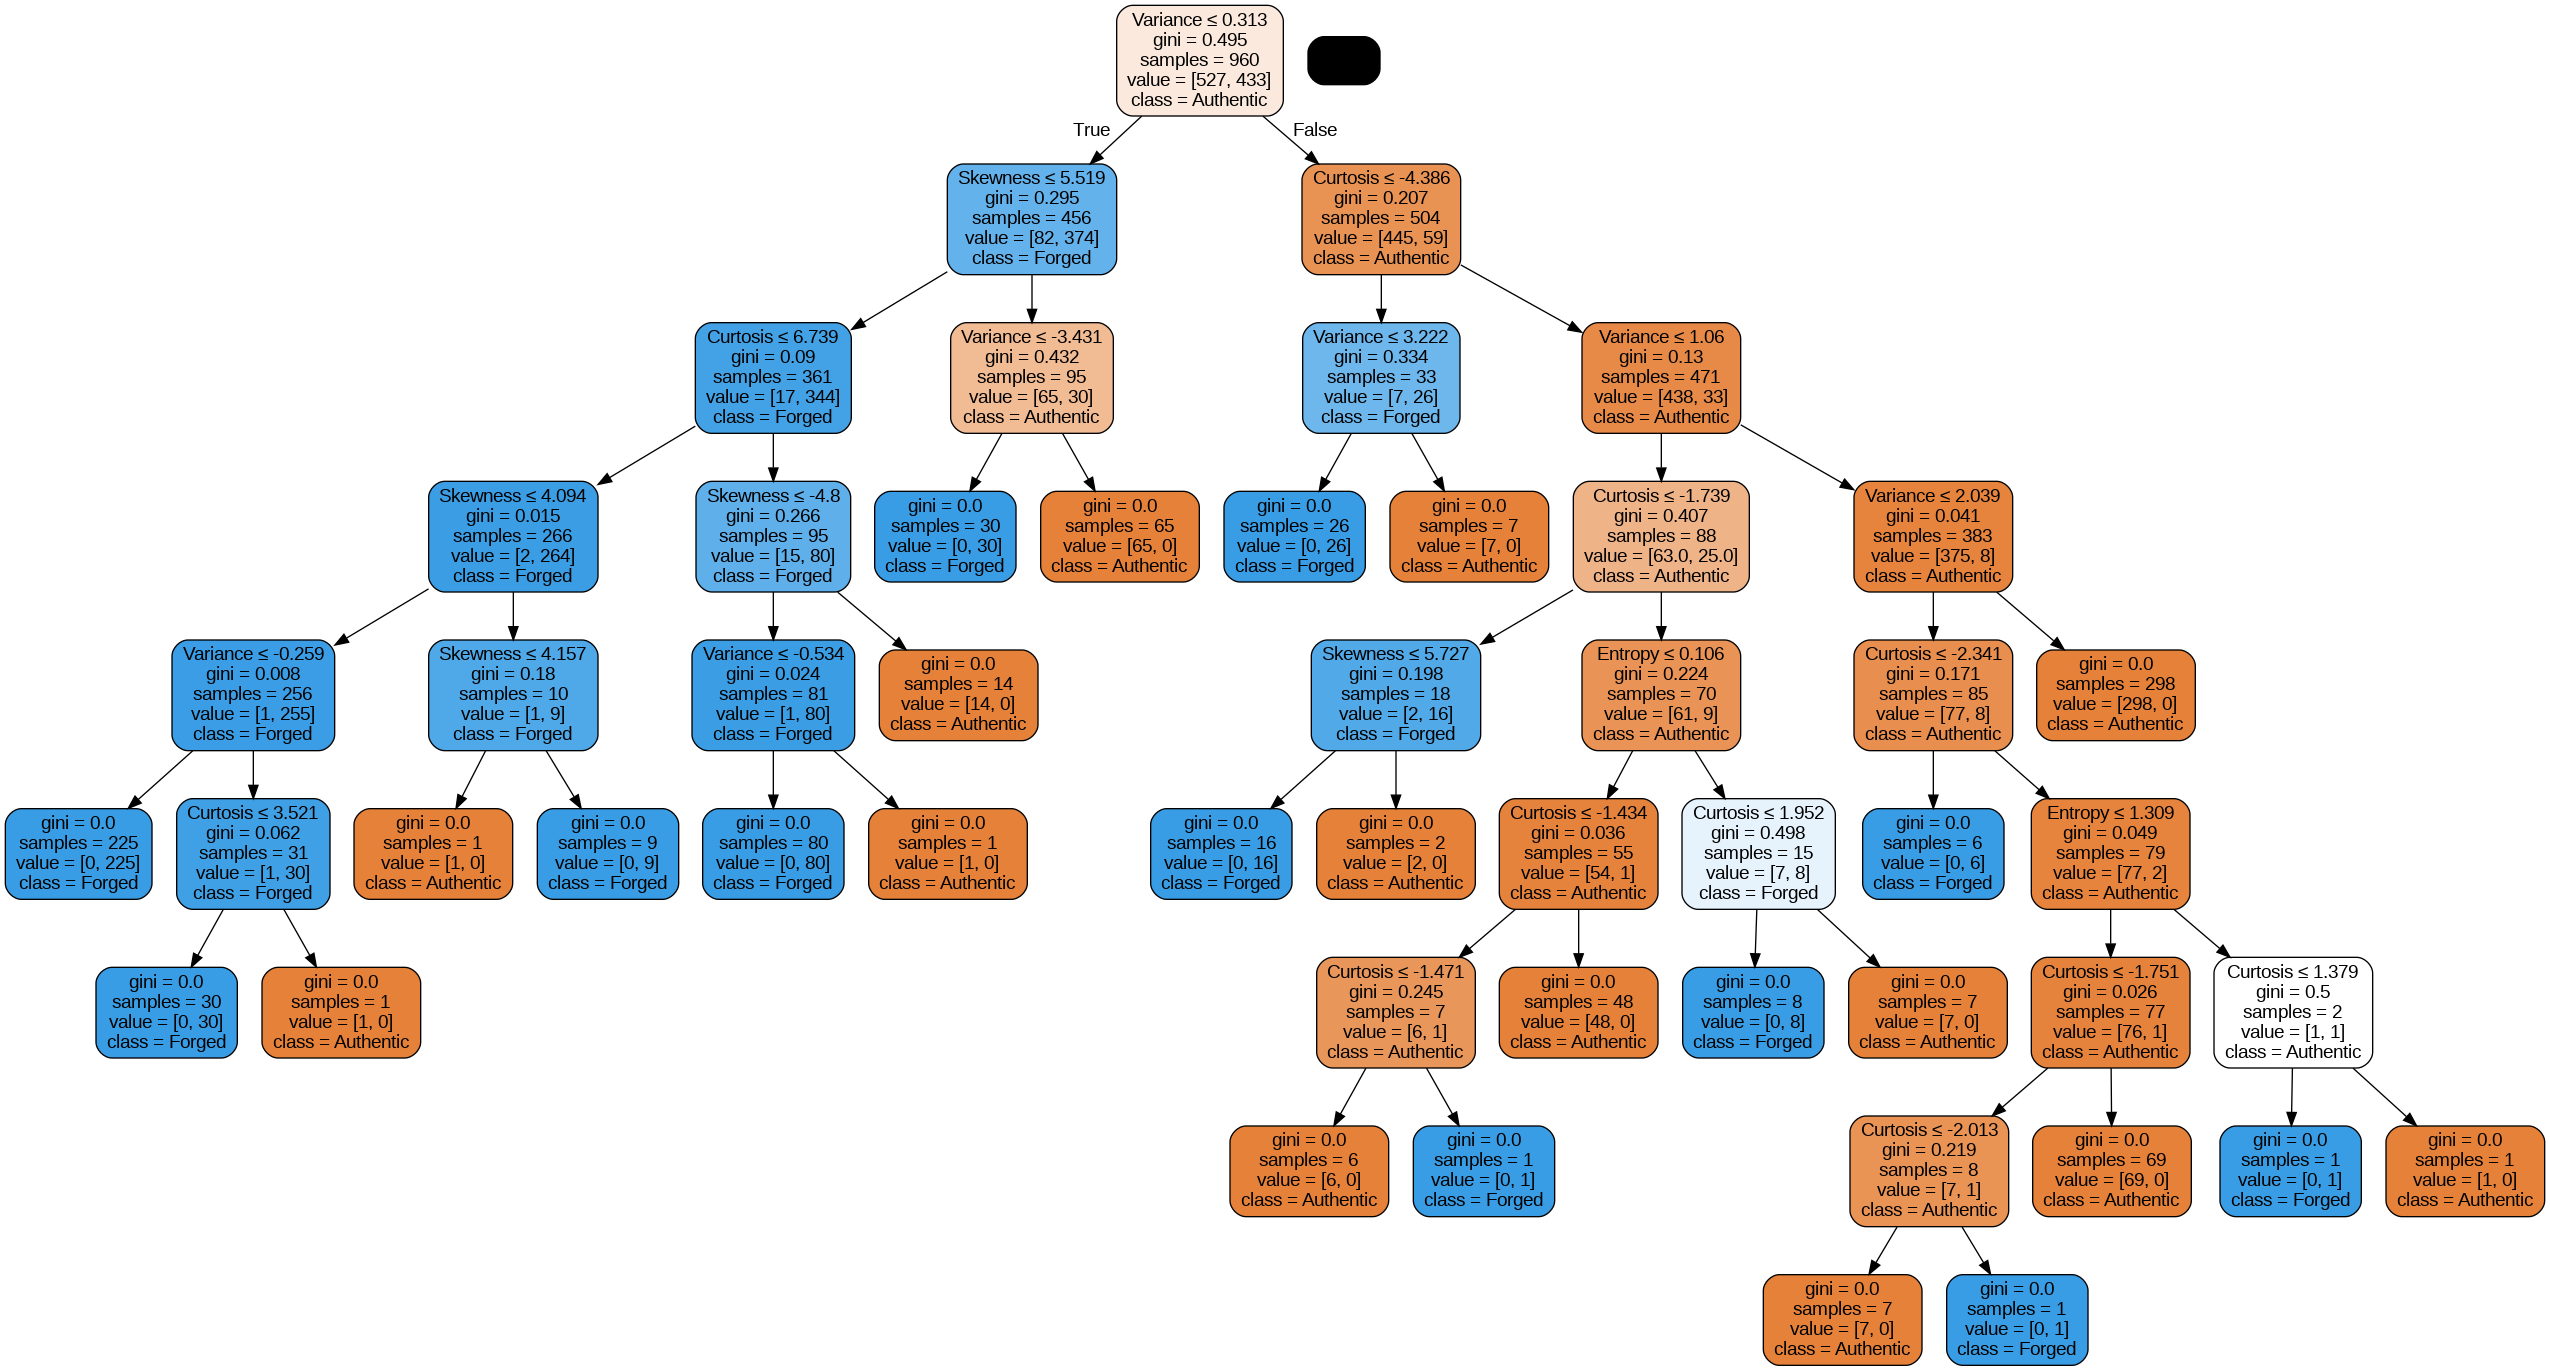

In [ ]:
!pip install graphviz
!pip install pydotplus
!pip install six

from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus


dot_data = StringIO()
export_graphviz(dt_model2, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=x_data.columns,
                class_names=['Authentic', 'Forged'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('banknote.png')
Image(graph.create_png())

The first split in the decision tree checks whether the variance is 0.313 or less. This is the models starting rule for seperating the banknotes into groups. At this point, the model is looking at 960 total records, with 527 authentic notes and 433 forged notes so it predicts authentic as the starting class. The gini value of 0.495 shows that this first group is still mixed which is why the data keeps splitting the data in smaller groups. So in conclusion, the first step shows how the model begins to narrow down the decisions before making a final classification.